In [10]:
## tools
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from dotenv import load_dotenv
import os
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [22]:
from sentence_transformers import SentenceTransformer, util
import torch
import pandas as pd
import numpy as np
import ast
from pandas import DataFrame
from dotenv import load_dotenv
from langchain_core.tools import tool
import psycopg2

def parse_pg_array(pg_array_string):
    """A simple function to parse a PostgreSQL array string into a Python list."""
    if not isinstance(pg_array_string, str) or not pg_array_string.startswith('{'):
        return pg_array_string
    if pg_array_string == '{}':
        return []
    # Strip the outer braces, remove quotes, and split by comma. This handles the specific format like '{"item1","item2",item3}'
    cleaned_string = pg_array_string.strip('{}').replace('"', '')
    return [item.strip() for item in cleaned_string.split(',')]

class ExerciseRecommender:
    """
    A content-based recommendation system for CBT exercises. It uses sentence embeddings to find the most relevant exercise based on a user's input.
    """
    def __init__(self, cbt_data: DataFrame):
        self.cbt_data = cbt_data.to_dict('records')
        self.model = SentenceTransformer('all-MiniLM-L6-v2')
        # Pre-compute embeddings for all exercise descriptions for efficiency
        self.search_documents = []
        for exercise in self.cbt_data:
            # Join the list of triggers into a single string
            trigger_text = " ".join(exercise.get('triggers', []))
            proactive_trigger_text = " ".join(exercise.get('proactive_triggers', []))
            # Combine all text fields into one document for embedding
            full_text = (
                f"Title: {exercise.get('category', '')}. "
                f"Title: {exercise.get('title', '')}. "
                f"Type: {exercise.get('exercise_type', '')}. "
                f"Goal: {exercise.get('goal', '')}. "
                f"Good for: {trigger_text} {proactive_trigger_text}. "
                f"How it works: {exercise.get('description', '')}"
            )
            self.search_documents.append(full_text)
        
        # Pre-compute embeddings for all the combined search documents
        self.exercise_embeddings = self.model.encode(self.search_documents, convert_to_tensor=True)

    def recommend_exercise(self, user_input: str):
        """
        Takes user's text input and returns the most relevant CBT exercise.
            
        Args:
            user_input: The text from the user (e.g., "I feel so stressed out").
                
        Returns:
            A dictionary containing the recommended exercise.
        """
        # Encode the user's input into a vector
        user_embedding = self.model.encode(user_input, convert_to_tensor=True)
        cosine_scores = util.cos_sim(user_embedding, self.exercise_embeddings)
        best_match_index = torch.argmax(cosine_scores).item()
        return self.cbt_data[best_match_index]

def initialize_recommender() -> ExerciseRecommender:
    """
    Connects to the DB, retrieves data, and returns an initialized recommender instance.
    This should only be run once when the application starts.
    """
    load_dotenv()
    db_url = os.getenv('DATABASE_URL')
    if not db_url:
        print("🔴 ERROR: DATABASE_URL environment variable is not set. Please check your .env file.")
        return None
    results = []
    try:
        with psycopg2.connect(db_url) as conn:
            with conn.cursor() as cur:
                query = f"SELECT * FROM cbt_exercise;"
                cur.execute(query)
                rows = cur.fetchall()
                colnames = [desc[0] for desc in cur.description]
                for row in rows:
                    results.append(dict(zip(colnames, row)))
        
        # Converting triggers and proactive_triggers into list
        if results:
            df = pd.DataFrame(results)
            list_columns = ['triggers', 'proactive_triggers']
            for col in list_columns:
                # Check if the column exists and if its first non-null value is a string
                if col in df.columns and df[col].notna().any() and isinstance(df[col].dropna().iloc[0], str):
                    # Apply the custom parsing function
                    df[col] = df[col].apply(lambda x: parse_pg_array(x) if pd.notna(x) else [])
            print("✅ Recommender initialized successfully.")
            return ExerciseRecommender(df)
            
    except psycopg2.errors.UndefinedTable as e:
        print(f"DATABASE TABLE ERROR: {e}")
        print("\n--- TROUBLESHOOTING ---")
        print(f"1. Make sure your table in Supabase is named exactly '{table_name}'.")
        print("2. Check for typos or singular vs. plural mismatches (e.g., 'cbt_exercise' vs 'cbt_exercises').")
        return None
    except psycopg2.OperationalError as e:
        print(f"DATABASE CONNECTION ERROR: {e}")
        print("\n--- TROUBLESHOOTING ---")
        print("1. Is your Supabase project paused? Free projects are paused after 1 week of inactivity.")
        print("2. Is the DATABASE_URL in your .env file correct?")
        return None
    except Exception as e:
        print(f"An unexpected error occurred during initialization: {e}")
        return None

# Initialize the recommender ONCE at the start.
recommender = initialize_recommender()

@tool
def recommend_coping_exercise(user_input: str) -> dict:
    """
    Use this tool when a user expresses feelings of distress, anxiety, sadness, stress, low motivation, lack of focus, or asks for a technique or exercise to help them manage their emotions.
    The input should be the user's most recent message describing their problem.
    """
    if recommender:
        return recommender.recommend_exercise(user_input)
    return {"error": "The recommender tool is currently unavailable due to an initialization error."}

✅ Recommender initialized successfully.


In [23]:
from typing_extensions import TypedDict 
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage, ToolMessage
from typing import Annotated ## labelling
from langgraph.graph.message import add_messages ## Reducers in LangGraph

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [24]:
from langchain_groq import ChatGroq
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.tools.arxiv.tool import ArxivQueryRun
from langchain_community.utilities.arxiv import ArxivAPIWrapper
from langchain_community.tools.wikipedia.tool import WikipediaQueryRun
from langchain_community.utilities.wikipedia import WikipediaAPIWrapper

arxiv_wrapper = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv_tool = ArxivQueryRun(api_wrapper=arxiv_wrapper)
        
wiki_wrapper = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500)
wiki_tool = WikipediaQueryRun(api_wrapper=wiki_wrapper)
        
tavily_tool = TavilySearchResults(max_results=2)

       
tools = [recommend_coping_exercise, arxiv_tool, wiki_tool, tavily_tool]

In [25]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import ChatOpenAI
load_dotenv()

system_prompt = """
You are a helpful and empathetic mental health assistant. Your primary goal is to support the user by providing a safe, non-judgemental space to explore their feelings.
Always maintain a supportive, patient, and non-judgmental tone.

1. If the user's query does not require a tool call:
- Respond empathetically.
- Always start by acknoledging the user's feelings
  - "That sounds incredibly difficult"
  - "It makes sense that you would feel that way."
- Instead of giving direct advice, gently ask clarifying questions to help the user elaborate. Use the 5W1H framework as a guide:
  - What happened that led to this feeling?
  - How has this been affecting your day?
  - When did this feeling start?

2. When your `recommend_coping_exercise` tool, returns one specific exercise:
- Start with a supportive statement acknowledging what the user is going through.
- Next, gently introduce the recommended exercise by its name.
  - Example: "I have a technique that might be helpful in moments like this. It's called [Name of Activity]"
- Clearly and briefly state the purpose of the exercise.
- Give the clear, numbered, step-by-step instructions provided by the tool.
- Your response must focus exclusively on the single recommended exercise. Do not add any other tips, suggestions, questions, or activities.

3. If the `recommend_coping_exercise` tool fails:
- DO NOT mention the error to the user.
- Only offer 1-2 simple if `recommend_coping_exercise` tool is not called.
 universally safe well-being tips (like deep breathing or a short walk).

For other tools like arxiv, wikipedia, or tavily:
- Summarize the findings in a clear and concise way
- Present the findings in your usual supportive and easy-to-understand tone, avoiding overly technical jargon.
"""

prompt = ChatPromptTemplate.from_messages(
            [
                ("system", system_prompt),
                MessagesPlaceholder(variable_name="messages"),
            ]
)

llm = ChatOpenAI(model="gpt-5-mini", api_key=os.getenv("OPENAI_API_KEY"), temperature = 0.2)
llm_with_tools = llm.bind_tools(tools)
chain = prompt | llm_with_tools

## Workflow

In [26]:
## Entire Chatbot with LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state: State):
    """The node that calls the LLM with a system prompt and tools."""
    # The 'chain' now includes the system prompt
    response = chain.invoke({"messages": state["messages"]})
    return {"messages": [response]}
    
## Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Build Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools _condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> toos_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "tool_calling_llm")
graph = builder.compile()

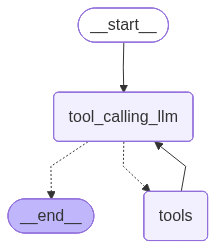

In [27]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
messages = graph.invoke({"messages": [HumanMessage(content="I feel exhausted. What should I do?")]})
final_messages = messages['messages']

for message in final_messages:
    message.pretty_print()

================================ Human Message =================================

I feel exhausted. What should I do?
================================== Ai Message ==================================
Tool Calls:
  recommend_coping_exercise (call_Q5GyByOSwPUfLKpiIMLOkfWj)
 Call ID: call_Q5GyByOSwPUfLKpiIMLOkfWj
  Args:
    user_input: I feel exhausted. What should I do?
================================= Tool Message =================================
Name: recommend_coping_exercise

{"id": 26, "category": "Bipolar Disorder", "title": "Activity Pacing", "triggers": ["I get overstimulated easily", "social events exhaust me", "need to balance my energy", "avoiding a manic episode", "recovering from a depressive episode", "I have so much energy I can't slow down", "I have no energy for anything"], "proactive_triggers": ["how to manage my energy with bipolar disorder", "a strategy for preventing mood swings", "a lifestyle tip for stability", "how to avoid burnout"], "goal": "To manage energy l